# Getting Started: Noise Scan for H2

This notebook performs a simple **noise scan** for the hydrogen molecule
**H2** using the packaged **VQE** workflow.

Goals:

- run the same VQE setup across a range of noise strengths
- compare depolarizing and amplitude-damping noise
- plot final energy as a function of noise level
- inspect convergence traces at a few representative settings

This is the basic noisy-VQE workflow in the repository.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import get_exact_spectrum
from vqe.core import run_vqe

## Why a noise scan?

In noiseless simulation, VQE targets the ideal variational energy for a given
ansatz and optimizer.

In noisy simulation, gate errors and relaxation effects can shift the returned
energy and alter the optimization trajectory.

A simple way to study this is to keep the molecule and optimizer fixed and vary
the noise strength.

## Exact reference energy

For `H2`, we use the exact ground-state energy as a common reference.

In [2]:
exact_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])
exact_ground_energy

-1.1372701748841751

## Fixed VQE settings

We keep the variational setup fixed across the scan.

In [3]:
molecule = "H2"
ansatz_name = "UCCSD"
optimizer_name = "Adam"
steps = 60
stepsize = 0.2
seed = 0

print("Molecule :", molecule)
print("Ansatz   :", ansatz_name)
print("Optimizer:", optimizer_name)

Molecule : H2
Ansatz   : UCCSD
Optimizer: Adam


## Noise grids

We scan:

- depolarizing probability with amplitude damping fixed at zero
- amplitude-damping probability with depolarizing noise fixed at zero

This keeps the two effects easy to interpret.

In [4]:
noise_levels = np.array([0.00, 0.01, 0.02, 0.05, 0.10], dtype=float)
noise_levels

array([0.  , 0.01, 0.02, 0.05, 0.1 ])

## Depolarizing-noise scan

In [5]:
dep_results = []
dep_final_energies = []

for p in noise_levels:
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        stepsize=stepsize,
        seed=seed,
        noisy=True,
        depolarizing_prob=float(p),
        amplitude_damping_prob=0.0,
        force=True,
        plot=False,
    )

    energy = float(res["energy"])
    dep_results.append(res)
    dep_final_energies.append(energy)

    print(f"Depolarizing p = {p:.3f} -> E = {energy:.10f} Ha")

Step 01/60: E = -1.116684 Ha
Step 02/60: E = -1.136994 Ha
Step 03/60: E = -1.131007 Ha
Step 04/60: E = -1.122700 Ha
Step 05/60: E = -1.130115 Ha
Step 06/60: E = -1.133031 Ha
Step 07/60: E = -1.134496 Ha
Step 08/60: E = -1.134652 Ha
Step 09/60: E = -1.132102 Ha
Step 10/60: E = -1.130839 Ha
Step 11/60: E = -1.133769 Ha
Step 12/60: E = -1.136856 Ha
Step 13/60: E = -1.136817 Ha
Step 14/60: E = -1.134837 Ha
Step 15/60: E = -1.133732 Ha
Step 16/60: E = -1.134458 Ha
Step 17/60: E = -1.135957 Ha
Step 18/60: E = -1.136742 Ha
Step 19/60: E = -1.136508 Ha
Step 20/60: E = -1.136055 Ha
Step 21/60: E = -1.135899 Ha
Step 22/60: E = -1.135938 Ha
Step 23/60: E = -1.136174 Ha
Step 24/60: E = -1.136688 Ha
Step 25/60: E = -1.137068 Ha
Step 26/60: E = -1.136886 Ha
Step 27/60: E = -1.136406 Ha
Step 28/60: E = -1.136270 Ha
Step 29/60: E = -1.136684 Ha
Step 30/60: E = -1.137181 Ha
Step 31/60: E = -1.137213 Ha
Step 32/60: E = -1.136850 Ha
Step 33/60: E = -1.136654 Ha
Step 34/60: E = -1.136858 Ha
Step 35/60: E 

In [6]:
dep_final_energies = np.asarray(dep_final_energies, dtype=float)
dep_final_energies

array([-1.13723474, -1.118823  , -1.10063821, -1.0472579 , -0.96202369])

## Amplitude-damping-noise scan

In [7]:
amp_results = []
amp_final_energies = []

for p in noise_levels:
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        stepsize=stepsize,
        seed=seed,
        noisy=True,
        depolarizing_prob=0.0,
        amplitude_damping_prob=float(p),
        force=True,
        plot=False,
    )

    energy = float(res["energy"])
    amp_results.append(res)
    amp_final_energies.append(energy)

    print(f"Amplitude damping p = {p:.3f} -> E = {energy:.10f} Ha")

Step 01/60: E = -1.116684 Ha
Step 02/60: E = -1.136994 Ha
Step 03/60: E = -1.131007 Ha
Step 04/60: E = -1.122700 Ha
Step 05/60: E = -1.130115 Ha
Step 06/60: E = -1.133031 Ha
Step 07/60: E = -1.134496 Ha
Step 08/60: E = -1.134652 Ha
Step 09/60: E = -1.132102 Ha
Step 10/60: E = -1.130839 Ha
Step 11/60: E = -1.133769 Ha
Step 12/60: E = -1.136856 Ha
Step 13/60: E = -1.136817 Ha
Step 14/60: E = -1.134837 Ha
Step 15/60: E = -1.133732 Ha
Step 16/60: E = -1.134458 Ha
Step 17/60: E = -1.135957 Ha
Step 18/60: E = -1.136742 Ha
Step 19/60: E = -1.136508 Ha
Step 20/60: E = -1.136055 Ha
Step 21/60: E = -1.135899 Ha
Step 22/60: E = -1.135938 Ha
Step 23/60: E = -1.136174 Ha
Step 24/60: E = -1.136688 Ha
Step 25/60: E = -1.137068 Ha
Step 26/60: E = -1.136886 Ha
Step 27/60: E = -1.136406 Ha
Step 28/60: E = -1.136270 Ha
Step 29/60: E = -1.136684 Ha
Step 30/60: E = -1.137181 Ha
Step 31/60: E = -1.137213 Ha
Step 32/60: E = -1.136850 Ha
Step 33/60: E = -1.136654 Ha
Step 34/60: E = -1.136858 Ha
Step 35/60: E 

In [8]:
amp_final_energies = np.asarray(amp_final_energies, dtype=float)
amp_final_energies

array([-1.13723474, -1.12500129, -1.11266008, -1.07486594, -1.00940095])

## Final energies vs noise strength

We compare the two noise models against the exact ground-state reference.

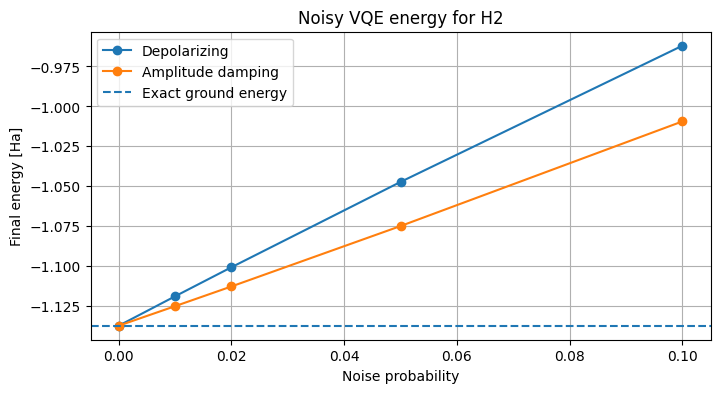

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(noise_levels, dep_final_energies, marker="o", label="Depolarizing")
plt.plot(noise_levels, amp_final_energies, marker="o", label="Amplitude damping")
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Noise probability")
plt.ylabel("Final energy [Ha]")
plt.title("Noisy VQE energy for H2")
plt.grid(True)
plt.legend()
plt.show()

## Energy error vs noise strength

Absolute error makes the noise effect easier to compare directly.

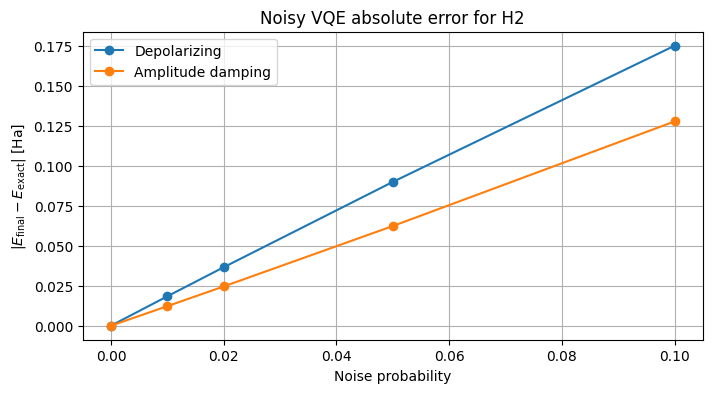

In [10]:
dep_abs_errors = np.abs(dep_final_energies - exact_ground_energy)
amp_abs_errors = np.abs(amp_final_energies - exact_ground_energy)

plt.figure(figsize=(8, 4))
plt.plot(noise_levels, dep_abs_errors, marker="o", label="Depolarizing")
plt.plot(noise_levels, amp_abs_errors, marker="o", label="Amplitude damping")
plt.xlabel("Noise probability")
plt.ylabel(r"$|E_{\mathrm{final}} - E_{\mathrm{exact}}|$ [Ha]")
plt.title("Noisy VQE absolute error for H2")
plt.grid(True)
plt.legend()
plt.show()

## Convergence traces at representative noise levels

Final energies are useful, but the optimization trajectories also matter.

We inspect:

- noiseless
- mild noise
- stronger noise

In [ ]:
representative_levels = [0.00, 0.02, 0.10]
rep_indices = [int(np.where(np.isclose(noise_levels, p))[0][0]) for p in representative_levels]

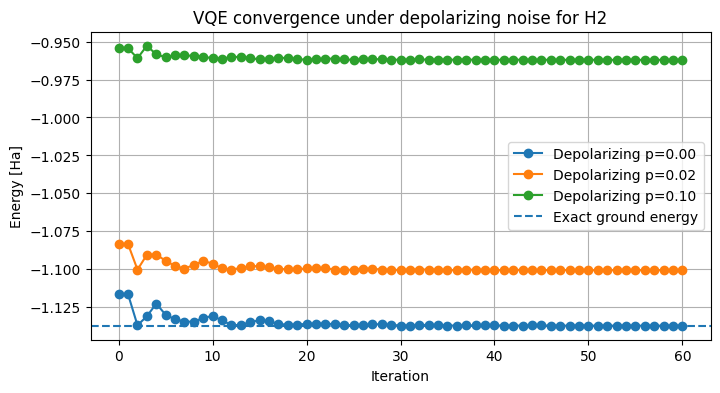

In [12]:
plt.figure(figsize=(8, 4))
for idx in rep_indices:
    p = float(noise_levels[idx])
    trace = np.asarray(dep_results[idx]["energies"], dtype=float)
    plt.plot(np.arange(len(trace)), trace, marker="o", label=f"Depolarizing p={p:.2f}")

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VQE convergence under depolarizing noise for H2")
plt.grid(True)
plt.legend()
plt.show()

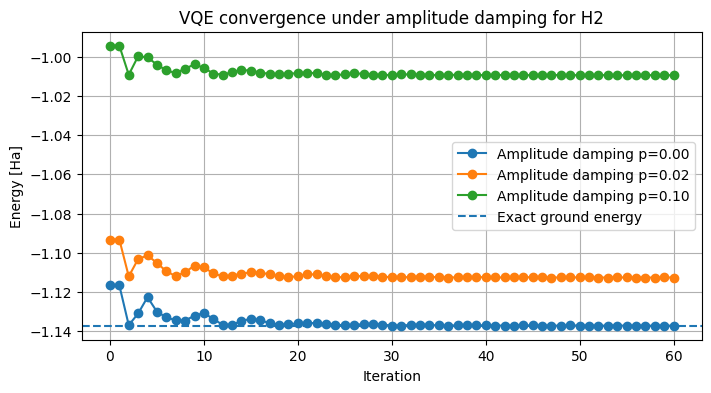

In [13]:
plt.figure(figsize=(8, 4))
for idx in rep_indices:
    p = float(noise_levels[idx])
    trace = np.asarray(amp_results[idx]["energies"], dtype=float)
    plt.plot(np.arange(len(trace)), trace, marker="o", label=f"Amplitude damping p={p:.2f}")

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VQE convergence under amplitude damping for H2")
plt.grid(True)
plt.legend()
plt.show()

## Tabulated results

In [14]:
print(f"{'Noise p':<10} {'Depolarizing E [Ha]':>22} {'Amplitude damping E [Ha]':>28}")
print("-" * 64)
for p, e_dep, e_amp in zip(noise_levels, dep_final_energies, amp_final_energies):
    print(f"{p:<10.3f} {e_dep:>22.10f} {e_amp:>28.10f}")

Noise p       Depolarizing E [Ha]     Amplitude damping E [Ha]
----------------------------------------------------------------
0.000               -1.1372347360                -1.1372347360
0.010               -1.1188230037                -1.1250012934
0.020               -1.1006382083                -1.1126600822
0.050               -1.0472579005                -1.0748659415
0.100               -0.9620236879                -1.0094009517


## Interpretation

The physical effect of a noise model depends on the channel:

- **depolarizing noise** tends to randomize the state
- **amplitude damping** drives population loss toward lower computational-basis
  levels

Because these channels act differently, two scans with the same nominal noise
probability do not generally produce the same optimization behavior or the same
final energy.

## What this notebook showed

We:

- ran `VQE` for `H2` across a grid of noise probabilities
- compared depolarizing and amplitude-damping noise
- plotted final energies and absolute errors
- inspected representative convergence traces

This is the basic noisy-VQE scan workflow in the repository.